### Imports

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
from collections import Counter
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,classification_report)
from exported_embeddings import ExportedEmbeddings
from datasets import load_dataset

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load dataset

In [3]:
dataset = load_dataset("lhoestq/conll2003")

train_data = dataset["train"]
val_data = dataset["validation"]
test_data = dataset["test"]

print(len(train_data))
print(len(val_data))
print(len(test_data))

14041
3250
3453


### Load embeddings

In [4]:
def load_embeddings():
    embeddings = ExportedEmbeddings(
    vectors_path="exports/word_vectors.npy",
    word_to_id_path="exports/word_to_id.json",
    id_to_word_path="exports/id_to_word.json"
    )
    return  embeddings


embeddings = load_embeddings()
embeddings_dim=embeddings.vectors.shape[1]

def get_embedding(word):
    word = word.lower()
    if word in embeddings:
        return embeddings.vector(word)
    else:
        return np.zeros(embeddings_dim)

print(embeddings_dim)
print(embeddings.vector("the")[:5])
print("alexandria" in embeddings)    

label_names = [
    "O",
    "B-PER",
    "I-PER",
    "B-ORG",
    "I-ORG",
    "B-LOC",
    "I-LOC",
    "B-MISC",
    "I-MISC"
]
num_classes = len(label_names)


32
[ 0.20172493 -0.30306906 -0.10933203 -0.90109724  0.09634292]
False


In [5]:
def prepare_dataset(split,window_size=1):
    X = []
    y = []

    for item in split:
        tokens = item["tokens"]
        labels = item["ner_tags"]

        for i in range(len(tokens)):
            window_embeddings = []

            for j in range(i - window_size, i + window_size + 1):
                if j < 0 or j >= len(tokens):
                    window_embeddings.append(np.zeros(embeddings_dim))
                else:
                    window_embeddings.append(get_embedding(tokens[j]))

            X.append(np.concatenate(window_embeddings))
            y.append(labels[i])

    X = torch.tensor(np.array(X), dtype=torch.float32)
    y = torch.tensor(np.array(y), dtype=torch.long)
    return X, y



### Class Imbalance --> Class O dominates

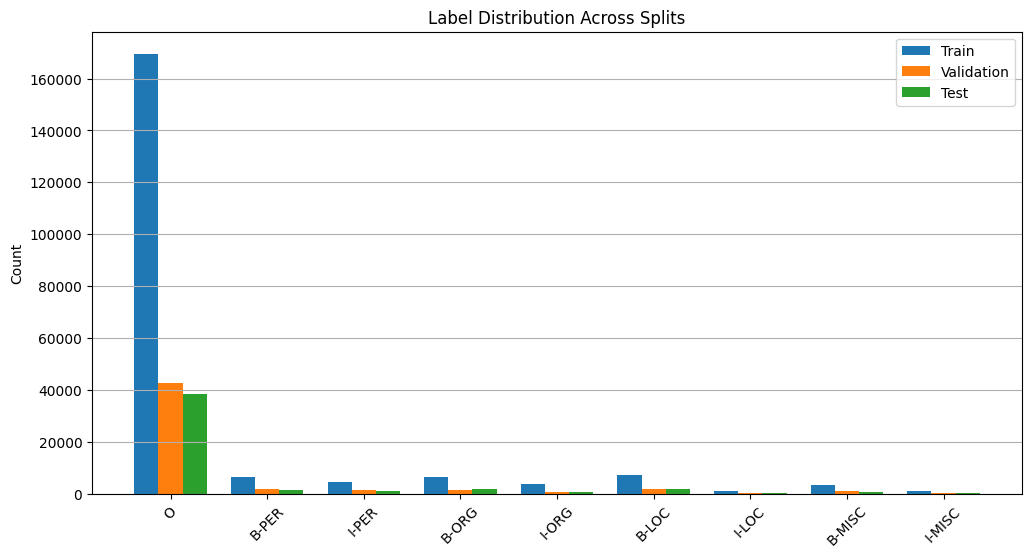

In [6]:
X_train, y_train = prepare_dataset(train_data)
X_val, y_val = prepare_dataset(val_data)
X_test, y_test = prepare_dataset(test_data)

train_counts = Counter(y_train.tolist())
val_counts = Counter(y_val.tolist())
test_counts = Counter(y_test.tolist())

train_vals = [train_counts.get(i, 0) for i in range(num_classes)]
val_vals = [val_counts.get(i, 0) for i in range(num_classes)]
test_vals = [test_counts.get(i, 0) for i in range(num_classes)]

x = np.arange(num_classes)
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(x - width, train_vals, width, label="Train")
plt.bar(x, val_vals, width, label="Validation")
plt.bar(x + width, test_vals, width, label="Test")

plt.xticks(x, label_names, rotation=45)
plt.ylabel("Count")
plt.title("Label Distribution Across Splits")
plt.legend()
plt.grid(axis='y')

plt.show()

### Feed Forward Neural Network NER Model

In [7]:
class FeedForwardModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes,dropout=0.3):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.fc2(self.dropout(x))
        return x

In [8]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0

    for X_batch, y_batch in loader:
        optimizer.zero_grad() #clear gradients
        logits = model(X_batch) #forward pass i/p -> prediction
        loss = criterion(logits, y_batch)
        loss.backward() #compute gradients
        optimizer.step() #update weights

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            logits = model(X_batch) #forward pass
            loss = criterion(logits, y_batch) #calc loss
            preds = torch.argmax(logits, dim=1)

            total_loss += loss.item()
            all_preds.extend(preds.tolist())
            all_labels.extend(y_batch.tolist())

    avg_loss = total_loss / len(loader)
    return avg_loss, all_labels, all_preds

# handles class imbalance give higher weights to rare tags and lower weight to frequent tags
def get_class_weights(y_tensor, num_classes):
    counts = Counter(y_tensor.tolist())
    total = sum(counts.values())

    weights = []
    for i in range(num_classes):
        count = counts.get(i, 1)   
        weights.append(total / count)

    weights = torch.tensor(weights, dtype=torch.float32)
    weights = weights / weights.sum() * num_classes
    return weights


def compute_metrics(y_true, y_pred, average="weighted"):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average=average, zero_division=0
    )
    return acc, precision, recall, f1

### Training and validation

In [9]:
configs = [
    {"window_size": 1, "hidden_dim": 128, "lr": 1e-3},
    {"window_size": 1, "hidden_dim": 256, "lr": 1e-3},
    {"window_size": 2, "hidden_dim": 128, "lr": 1e-3},
    {"window_size": 2, "hidden_dim": 256, "lr": 5e-4},
]

best_config = None
best_val_f1 = -1
best_state_dict = None
best_history = None

for config in configs:
    print("Trying config:", config)

    X_train, y_train = prepare_dataset(train_data, window_size=config["window_size"])
    X_val, y_val = prepare_dataset(val_data, window_size=config["window_size"])
    class_weights = get_class_weights(y_train, num_classes)

    train_dataset = TensorDataset(X_train, y_train)
    val_dataset = TensorDataset(X_val, y_val)

    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

    input_dim = X_train.shape[1]

    model = FeedForwardModel(
        input_dim=input_dim,
        hidden_dim=config["hidden_dim"],
        num_classes=num_classes,
    )

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])

    train_losses = []
    val_losses = []
    val_f1s = []

    local_best_f1 = -1
    local_best_state = None

    for epoch in range(10):
        train_loss = train_epoch(model, train_loader, optimizer, criterion)
        val_loss, y_val_true, y_val_pred = evaluate(model, val_loader, criterion)
        val_acc, val_prec, val_rec, val_f1 = compute_metrics(y_val_true, y_val_pred)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_f1s.append(val_f1)

        print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, val_f1={val_f1:.4f}")

        if val_f1 > local_best_f1:
            local_best_f1 = val_f1
            local_best_state = deepcopy(model.state_dict())

    if local_best_f1 > best_val_f1:
        best_val_f1 = local_best_f1
        best_config = config
        best_state_dict = local_best_state
        best_history = {
            "train_losses": train_losses,
            "val_losses": val_losses,
            "val_f1s": val_f1s
        }

print("Best config:", best_config)
print("Best validation F1:", best_val_f1)

Trying config: {'window_size': 1, 'hidden_dim': 128, 'lr': 0.001}
Epoch 1: train_loss=0.3918, val_loss=0.2756, val_f1=0.9104
Epoch 2: train_loss=0.2707, val_loss=0.2455, val_f1=0.9232
Epoch 3: train_loss=0.2466, val_loss=0.2328, val_f1=0.9263
Epoch 4: train_loss=0.2343, val_loss=0.2280, val_f1=0.9271
Epoch 5: train_loss=0.2264, val_loss=0.2207, val_f1=0.9302
Epoch 6: train_loss=0.2193, val_loss=0.2130, val_f1=0.9349
Epoch 7: train_loss=0.2146, val_loss=0.2138, val_f1=0.9338
Epoch 8: train_loss=0.2090, val_loss=0.2122, val_f1=0.9349
Epoch 9: train_loss=0.2070, val_loss=0.2069, val_f1=0.9374
Epoch 10: train_loss=0.2031, val_loss=0.2059, val_f1=0.9367
Trying config: {'window_size': 1, 'hidden_dim': 256, 'lr': 0.001}
Epoch 1: train_loss=0.3545, val_loss=0.2598, val_f1=0.9145
Epoch 2: train_loss=0.2462, val_loss=0.2299, val_f1=0.9274
Epoch 3: train_loss=0.2224, val_loss=0.2167, val_f1=0.9319
Epoch 4: train_loss=0.2084, val_loss=0.2094, val_f1=0.9351
Epoch 5: train_loss=0.1977, val_loss=0.20

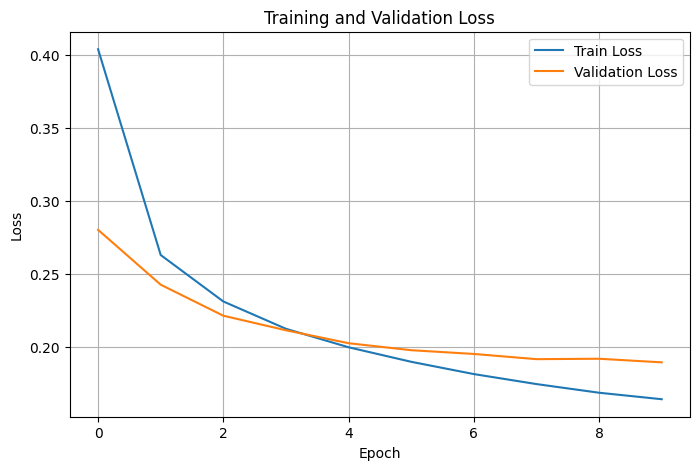

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(best_history["train_losses"], label="Train Loss")
plt.plot(best_history["val_losses"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

### Evaluation on test data

In [11]:
X_train_best, y_train_best = prepare_dataset(train_data, window_size=best_config["window_size"])
X_test, y_test = prepare_dataset(test_data, window_size=best_config["window_size"])

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

best_model = FeedForwardModel(
    input_dim=X_train_best.shape[1],
    hidden_dim=best_config["hidden_dim"],
    num_classes=num_classes,
)

best_model.load_state_dict(best_state_dict)

_, y_test_true, y_test_pred = evaluate(best_model, test_loader, criterion)
test_acc, test_prec, test_rec, test_f1 = compute_metrics(y_test_true, y_test_pred, average="weighted")

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1 (weighted): {test_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test_true,
    y_test_pred,
    target_names=label_names,
    zero_division=0
))

Test Accuracy: 0.9346
Test F1 (weighted): 0.9305

Classification Report:
              precision    recall  f1-score   support

           O       0.95      0.99      0.97     38323
       B-PER       0.89      0.80      0.84      1617
       I-PER       0.91      0.80      0.86      1156
       B-ORG       0.78      0.62      0.69      1661
       I-ORG       0.74      0.50      0.60       835
       B-LOC       0.87      0.77      0.82      1668
       I-LOC       0.80      0.60      0.68       257
      B-MISC       0.79      0.49      0.60       702
      I-MISC       0.53      0.50      0.52       216

    accuracy                           0.93     46435
   macro avg       0.81      0.67      0.73     46435
weighted avg       0.93      0.93      0.93     46435

